# Introdução
- Visto que o tratamento textual mais robusto não surgiu muito efeito, este estudo tem como objetivo escolher um número adequado para de features, ou melhor, o número adequado para o parâmetro "k_use": SelectKBest(chi2, k=k_use).
- O procedimento de escolha ficará automatizado nos estudos subsequentes.

# Imports e configs

In [1]:
import pandas as pd
from tqdm.auto import tqdm
import os
import re
import numpy as np
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score, 
    balanced_accuracy_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns

tqdm.pandas()

# Configs
split_path = '../data/split'
seed = 2025

import warnings
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*", category=UserWarning)

# Recuperação dos datasets

In [2]:
df_train_val = pd.read_csv('../data/split/train_val_set.csv')
df_train_val['text'] = df_train_val['title'] + ' ' + df_train_val['summary']
df_test = pd.read_csv('../data/split/test_set.csv')
df_test['text'] = df_test['title'] + ' ' + df_test['summary']
df_train_val.head(2)

,id,title,author,publication_date,summary,label,fold,text
0,620,animal farm,george orwell,1945.0,old major the old boar on the manor farm calls...,0,fold_3,animal farm old major the old boar on the mano...
1,843,a clockwork orange,anthony burgess,1962.0,alex a teenager living in nearfuture england l...,0,fold_2,a clockwork orange alex a teenager living in n...


# Rotinas avaliação

In [3]:
# =========================
# HELPERS DE MÉTRICAS/FORMATAÇÃO
# =========================
def roc_auc_safe(y_true, proba, classes_in_proba):
    """AUC binário ou OVR weighted para multi, robusto ao índice da classe positiva."""
    if len(classes_in_proba) == 2:
        pos_label = classes_in_proba[-1]
        pos_idx = list(classes_in_proba).index(pos_label)
        return roc_auc_score(y_true, proba[:, pos_idx])
    return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")


def gmeans_safe(y_true, y_pred, labels_sorted):
    uniq = np.unique(y_true)
    if len(uniq) == 2:
        pos_label = labels_sorted[-1]
        g_bin = geometric_mean_score(y_true, y_pred, average="binary", pos_label=pos_label)
    else:
        g_bin = np.nan
    g_micro = geometric_mean_score(y_true, y_pred, average="micro")
    return g_bin, g_micro


def format_summary(results_detailed):
    rows = []
    for entry in results_detailed:
        row = {"Modelo": entry["Modelo"]}
        for metric, values in entry.items():
            if metric == "Modelo":
                continue
            arr = np.array(values, dtype=float)
            row[metric] = f"{np.mean(arr):.2f} ({np.min(arr):.2f}-{np.max(arr):.2f}) ± {np.std(arr, ddof=1):.2f}"
        rows.append(row)
    return pd.DataFrame(rows)


# =========================
# CROSS-VALIDATION (com Chi² opcional)
# =========================
def run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold,
              select_k=None, seed=2025, plot=False):

    fold_metrics, cms, cms_norm = [], [], []
    print(f"[{model_name}] Chi2_K={select_k}")

    for fold in tqdm(sorted(df['fold'].unique()), desc=f"Folds {model_name}", leave=True):
        # split
        train_mask = df['fold'] != fold
        val_mask   = ~train_mask

        X_train_text = df.loc[train_mask, 'text'].astype(str).values
        X_val_text   = df.loc[val_mask, 'text'].astype(str).values
        y_train = df.loc[train_mask, 'label'].values
        y_val   = df.loc[val_mask, 'label'].values

        # TF-IDF
        vect = TfidfVectorizer()
        X_train_full = vect.fit_transform(X_train_text)
        X_val_full   = vect.transform(X_val_text)

        # Seleção de features (Chi²)
        if select_k is not None:
            k_use = min(int(select_k), X_train_full.shape[1])
            selector = SelectKBest(chi2, k=k_use)
            X_train = selector.fit_transform(X_train_full, y_train)
            X_val   = selector.transform(X_val_full)
        else:
            X_train, X_val = X_train_full, X_val_full

        # treino
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight='balanced', y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        # validação
        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)

        g_bin, g_micro = gmeans_safe(y_val, preds, labels_sorted)
        metrics = {
            "Accuracy": accuracy_score(y_val, preds),
            "Precision": precision_score(y_val, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_val, preds, average="macro", zero_division=0),
            "F1": f1_score(y_val, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_val, preds),
            "GMean": g_bin,
            "GMeanMicro": g_micro,
            "AUPRC": average_precision_score(y_val, proba[:, 1])
        }
        fold_metrics.append(metrics)

        cm  = confusion_matrix(y_val, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_val, preds, labels=labels_sorted, normalize="true")
        cms.append(cm); cms_norm.append(cmn)

        if log_each_fold:
            msg = " | ".join([f"{k}={v:.3f}" for k, v in metrics.items() if not np.isnan(v)])
            print(f"{model_name} | fold={fold} | {msg}")

    mean_cm = np.rint(np.mean(cms, axis=0)).astype(int)
    mean_cm_norm = np.mean(cms_norm, axis=0)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        sns.heatmap(mean_cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        sns.heatmap(mean_cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        plt.tight_layout()
        plt.show()

    return fold_metrics, mean_cm, mean_cm_norm


def evaluate_models(df, seed, use_class_weight=False, log_each_fold=False,
                    select_k=None, plot=False):

    labels_sorted = np.array(sorted(df['label'].unique()))
    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight":"balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight":"balanced"} if use_class_weight else {})
        ),
    }

    rows_mean, results_detailed = [], []

    for model_name, model in models.items():
        start = time.perf_counter()
        fold_metrics, mean_cm, mean_cm_norm = run_folds(
            model, model_name, df, labels_sorted, use_class_weight, log_each_fold,
            select_k=select_k, seed=seed, plot=plot
        )
        elapsed = time.perf_counter() - start

        mean_vals = {k: np.nanmean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
        mean_vals.update({"Modelo": model_name, "Tempo_s": round(elapsed, 2)})
        if select_k is not None:
            mean_vals.update({"Chi2_K": select_k})
        rows_mean.append(mean_vals)

        detailed_vals = {"Modelo": model_name}
        for k in fold_metrics[0]:
            detailed_vals[k] = [m[k] for m in fold_metrics]
        results_detailed.append(detailed_vals)

    metrics_df = pd.DataFrame(rows_mean).round(3)
    metrics_summary = format_summary(results_detailed)
    return metrics_df, metrics_summary


# =========================
# TESTE HOLD-OUT (com Chi² opcional)
# =========================
def evaluate_on_test(train_df, test_df, seed, use_class_weight=False, select_k=None, plot=False):
    labels_sorted = np.array(sorted(train_df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
    }

    X_train_text = train_df['text'].astype(str).values
    y_train = train_df['label'].values
    X_test_text  = test_df['text'].astype(str).values
    y_test       = test_df['label'].values

    rows = []
    for model_name, model in models.items():
        vect = TfidfVectorizer()
        X_train_full = vect.fit_transform(X_train_text)
        X_test_full  = vect.transform(X_test_text)

        if select_k is not None:
            k_use = min(int(select_k), X_train_full.shape[1])
            selector = SelectKBest(chi2, k=k_use)
            X_train_use = selector.fit_transform(X_train_full, y_train)
            X_test_use  = selector.transform(X_test_full)
        else:
            X_train_use, X_test_use = X_train_full, X_test_full

        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight="balanced", y=y_train)
            model.fit(X_train_use, y_train, sample_weight=sw)
        else:
            model.fit(X_train_use, y_train)

        preds = model.predict(X_test_use)
        proba = model.predict_proba(X_test_use)

        g_bin, g_micro = gmeans_safe(y_test, preds, labels_sorted)
        metrics = {
            "Modelo": model_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_test, preds, average="macro", zero_division=0),
            "F1": f1_score(y_test, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_test, preds),
            "GMean": g_bin,
            "GMeanMicro": g_micro,
            "AUPRC": average_precision_score(y_test, proba[:, 1])
        }
        if select_k is not None:
            metrics["Chi2_K"] = select_k
        rows.append(metrics)

        if plot:
            cm  = confusion_matrix(y_test, preds, labels=labels_sorted)
            cmn = confusion_matrix(y_test, preds, labels=labels_sorted, normalize="true")
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                        xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
            sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                        xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(rows).round(3)


# =========================
# GRID DE K PARA CHI²
# =========================
def chi2_grid():
    return (
        list(range(100, 1001, 100)) +
        list(range(2000, 10001, 1000)) +
        list(range(20000, 100001, 10000))
    )


# =========================
# OUTROS AUXILIARES
# =========================
def get_train_test_by_total_with_folds(df_total):
    df = df_total.copy()
    df_test = df[df['fold'] == 'test'].copy().reset_index(drop=True)
    df_train_val = df[df['fold'] != 'test'].copy().reset_index(drop=True)
    return df_test, df_train_val


# =========================
# VISUALIZAÇÃO DE RESULTADOS
# =========================
def _parse_metric_float(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.floating)): return float(x)
    m = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", str(x))
    return float(m.group()) if m else np.nan

def plot_metrics_all_in_one_per_model(
    df_cv_final,
    metrics=None,           # lista de métricas; None = detecta a partir do conjunto padrão existente no DF
    drop_baseline=True,     # remove k == "baseline"
    out_dir=None,           # pasta para salvar PNGs; None = só mostrar
    dpi=120,
    ylim=(0, 1),            # limites do eixo y (None = auto)
    marker_cycle=("o","s","^","D","P","X","v",">","<"),
    linestyle_cycle=("-", "--", "-.", ":"),
    dup_jitter=0.08,        # deslocamento horizontal entre séries idênticas
    round_equal=6           # casas decimais para decidir se duas séries são "iguais"
):
    df = df_cv_final.copy()
    if "k" not in df.columns:       raise ValueError("df_cv_final precisa ter a coluna 'k'.")
    if "Modelo" not in df.columns:  raise ValueError("df_cv_final precisa ter a coluna 'Modelo'.")

    if drop_baseline:
        df = df[df["k"] != "baseline"].copy()
        if df.empty:
            print("Nada para plotar após remover k='baseline'.")
            return None

    default_metrics = ["Accuracy","Precision","Recall","F1",
                       "BalancedAccuracy","GMean","GMeanMicro","AUPRC"]
    if metrics is None:
        metrics = [m for m in default_metrics if m in df.columns]
        if not metrics:
            raise ValueError("Nenhuma das métricas padrão foi encontrada no DataFrame.")
    else:
        missing = [m for m in metrics if m not in df.columns]
        if missing:
            raise ValueError(f"Métricas ausentes no DF: {missing}")

    # converter métricas em float
    for mcol in metrics:
        df[mcol] = pd.to_numeric(df[mcol].apply(_parse_metric_float), errors="coerce")

    # agrega por Modelo e k (média se houver várias linhas por k)
    df_agg = df.groupby(["Modelo","k"], as_index=False)[metrics].mean()

    # ordenar k numericamente quando possível
    df_agg["_k_num"] = pd.to_numeric(df_agg["k"], errors="coerce")
    order_k = df_agg.drop_duplicates("k").sort_values(["_k_num","k"])["k"].tolist()

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # uma figura por modelo
    for modelo, dmod in df_agg.groupby("Modelo"):
        dmod = dmod.copy()
        dmod["_k"] = pd.Categorical(dmod["k"], categories=order_k, ordered=True)
        dmod = dmod.sort_values("_k")

        # posições numéricas para permitir jitter horizontal
        x_labels = dmod["_k"].astype(str).tolist()
        x_pos = np.arange(len(x_labels))

        # detectar grupos de séries idênticas (após arredondar)
        series_map = {}
        for m in metrics:
            key = tuple(np.round(dmod[m].values.astype(float), round_equal))
            series_map.setdefault(key, []).append(m)

        # offsets por grupo de duplicatas
        offset_map = {}
        for key, mlist in series_map.items():
            g = len(mlist)
            if g == 1:
                offset_map[mlist[0]] = 0.0
            else:
                # offsets simétricos, ex.: g=2 -> [-d/2, +d/2], g=3 -> [-d, 0, +d]
                base = np.linspace(-(g-1)/2, (g-1)/2, g) * dup_jitter
                for met, off in zip(mlist, base):
                    offset_map[met] = off

        # plot
        plt.figure(figsize=(10, 5))
        for i, m in enumerate(metrics):
            off = offset_map.get(m, 0.0)
            ls  = linestyle_cycle[i % len(linestyle_cycle)]
            mk  = marker_cycle[i % len(marker_cycle)]
            plt.plot(x_pos + off, dmod[m].values, linestyle=ls, marker=mk, label=m)

        plt.xticks(x_pos, x_labels, rotation=45)
        plt.xlabel("k")
        plt.ylabel("valor")
        plt.title(f"Métricas por k — {modelo}")
        plt.grid(True, axis="y", linestyle="--", linewidth=0.6)
        if ylim is not None:
            plt.ylim(*ylim)
        plt.legend(title="Métrica", ncol=2)
        plt.tight_layout()

        if out_dir:
            fname = f"metrics_allinone_{str(modelo).replace(' ', '_')}.png"
            plt.savefig(os.path.join(out_dir, fname), dpi=dpi, bbox_inches="tight")
            print(f"[saved] {os.path.join(out_dir, fname)}")

        plt.show()

    return df_agg


### Validação cruzada

In [4]:
results_cv_all = []

for k in chi2_grid():
    print(f"\n=== Rodando CV com k={k} ===")

    metrics_df, metrics_summary = evaluate_models(
        df_train_val,
        seed=2025,
        use_class_weight=True,
        log_each_fold=False,
        select_k=k
    )
    metrics_summary["k"] = k
    results_cv_all.append(metrics_summary)

df_cv_final = pd.concat(results_cv_all, ignore_index=True)
display(df_cv_final)


=== Rodando CV com k=100 ===
[NaiveBayes] Chi2_K=100


Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

[LogisticRegression] Chi2_K=100


Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] Chi2_K=100


...

[LogisticRegression] Chi2_K=100000


Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] Chi2_K=100000


Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,k
0,NaiveBayes,0.23 (0.07-0.31) ± 0.11,0.48 (0.47-0.49) ± 0.01,0.40 (0.34-0.44) ± 0.04,0.19 (0.07-0.25) ± 0.08,0.40 (0.34-0.44) ± 0.04,0.32 (0.20-0.38) ± 0.07,0.23 (0.07-0.31) ± 0.11,0.21 (0.15-0.28) ± 0.04,100
1,LogisticRegression,0.95 (0.92-0.97) ± 0.02,0.60 (0.57-0.67) ± 0.04,0.67 (0.58-0.73) ± 0.06,0.62 (0.58-0.66) ± 0.03,0.67 (0.58-0.73) ± 0.06,0.60 (0.44-0.69) ± 0.11,0.95 (0.92-0.97) ± 0.02,0.21 (0.13-0.28) ± 0.06,100
2,LightGBM,0.94 (0.92-0.96) ± 0.02,0.58 (0.56-0.61) ± 0.02,0.67 (0.57-0.75) ± 0.06,0.60 (0.57-0.63) ± 0.03,0.67 (0.57-0.75) ± 0.06,0.60 (0.40-0.72) ± 0.12,0.94 (0.92-0.96) ± 0.02,0.27 (0.10-0.37) ± 0.10,100
3,NaiveBayes,0.36 (0.30-0.42) ± 0.05,0.49 (0.49-0.49) ± 0.00,0.40 (0.37-0.45) ± 0.04,0.28 (0.25-0.31) ± 0.02,0.40 (0.37-0.45) ± 0.04,0.39 (0.36-0.43) ± 0.03,0.36 (0.30-0.42) ± 0.05,0.23 (0.15-0.28) ± 0.05,200
4,LogisticRegression,0.95 (0.95-0.96) ± 0.00,0.62 (0.61-0.64) ± 0.02,0.72 (0.67-0.78) ± 0.04,0.66 (0.63-0.69) ± 0.02,0.72 (0.67-0.78) ± 0.04,0.68 (0.59-0.76) ± 0.06,0.95 (0.95-0.96) ± 0.00,0.30 (0.23-0.37) ± 0.06,200
...,...,...,...,...,...,...,...,...,...,...
79,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05,90000
80,LightGBM,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03,90000
81,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.68 (0.65-0.70) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.74 (0.70-0.77) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.89 (0.84-0.94) ± 0.04,0.96 (0.95-0.97) ± 0.01,0.73 (0.68-0.81) ± 0.05,100000
82,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05,100000


### Avaliação no conjunto de teste

In [5]:
results_test_all = []

for k in chi2_grid():
    print(f"\n=== Rodando Teste com k={k} ===")

    df_test_res = evaluate_on_test(
        df_train_val,
        df_test,
        seed=2025,
        use_class_weight=True,
        select_k=k
    )
    df_test_res["k"] = k
    results_test_all.append(df_test_res)

df_test_final = pd.concat(results_test_all, ignore_index=True)
display(df_test_final)


=== Rodando Teste com k=100 ===

=== Rodando Teste com k=200 ===

=== Rodando Teste com k=300 ===

=== Rodando Teste com k=400 ===

=== Rodando Teste com k=500 ===

=== Rodando Teste com k=600 ===

=== Rodando Teste com k=700 ===

=== Rodando Teste com k=800 ===

=== Rodando Teste com k=900 ===

=== Rodando Teste com k=1000 ===

=== Rodando Teste com k=2000 ===

=== Rodando Teste com k=3000 ===

=== Rodando Teste com k=4000 ===

=== Rodando Teste com k=5000 ===

=== Rodando Teste com k=6000 ===

=== Rodando Teste com k=7000 ===

=== Rodando Teste com k=8000 ===

=== Rodando Teste com k=9000 ===

=== Rodando Teste com k=10000 ===

=== Rodando Teste com k=20000 ===

=== Rodando Teste com k=30000 ===

=== Rodando Teste com k=40000 ===

=== Rodando Teste com k=50000 ===

=== Rodando Teste com k=60000 ===

=== Rodando Teste com k=70000 ===

=== Rodando Teste com k=80000 ===

=== Rodando Teste com k=90000 ===

=== Rodando Teste com k=100000 ===


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,Chi2_K,k
0,NaiveBayes,0.308,0.484,0.355,0.245,0.355,0.352,0.308,0.145,100,100
1,LogisticRegression,0.932,0.580,0.702,0.608,0.702,0.659,0.932,0.153,100,100
2,LightGBM,0.903,0.533,0.608,0.541,0.608,0.523,0.903,0.125,100,100
3,NaiveBayes,0.340,0.488,0.385,0.266,0.385,0.382,0.340,0.147,200,200
4,LogisticRegression,0.946,0.575,0.630,0.594,0.630,0.535,0.946,0.177,200,200
...,...,...,...,...,...,...,...,...,...,...,...
79,LogisticRegression,0.986,0.871,0.822,0.844,0.822,0.803,0.986,0.643,90000,90000
80,LightGBM,0.982,0.887,0.701,0.763,0.701,0.636,0.982,0.609,90000,90000
81,NaiveBayes,0.958,0.676,0.900,0.739,0.900,0.897,0.958,0.643,100000,100000
82,LogisticRegression,0.986,0.871,0.822,0.844,0.822,0.803,0.986,0.646,100000,100000


# Save Results

In [6]:
# Caminhos relativos baseline
cv_path   = "../results/baseline/cv_baseline.csv"
test_path = "../results/baseline/test_baseline.csv"

# Carregar
df_cv   = pd.read_csv(cv_path)
df_test = pd.read_csv(test_path)

df_cv_final = pd.concat([df_cv_final, df_cv], ignore_index=True).fillna('baseline')
df_test_final = pd.concat([df_test_final, df_test], ignore_index=True).fillna('baseline')

# Caminho da pasta de saída
out_dir = "../results/chi"
os.makedirs(out_dir, exist_ok=True)

# Salvar arquivos
df_cv_final.to_csv(os.path.join(out_dir, "cv_chi.csv"), index=False)
df_test_final.to_csv(os.path.join(out_dir, "test_chi.csv"), index=False)

print("Arquivos salvos em:", out_dir)

Arquivos salvos em: ../results/chi


# Vizualização dos resultados sobre validação cruzada
- De modo geral, pode-se perceber que um valor abaixo de 3-5K produz um desempenho baixo de métricas que acompanham recall, ball_acc, etc.
- Nota-se que para NB, acima de 10K há a conhecida "troca de recall por precision", em que aumentar uma dessas métricas praticamente implica em reduzir a outra.
    - Isso nem sempre é ruim, pois pode-se preferir a ball_acc como métrica, por exemplo, quando os erros da classe majoritária e a precision da minoritária são menos importantes.

# Definição do fator k_use
- O mais justo é escolher esse valor antes de se ver o conjunto de teste, e devido à estabilidade em regioẽos pŕoximas e com menores K, define-se K=10_000 para os estudos subsequentes.
    - Talvez se por algum motivo, depois, quisermos procurar pela maior bal_acc possível, o NB com valores totais de features pode ser um bom candidato.

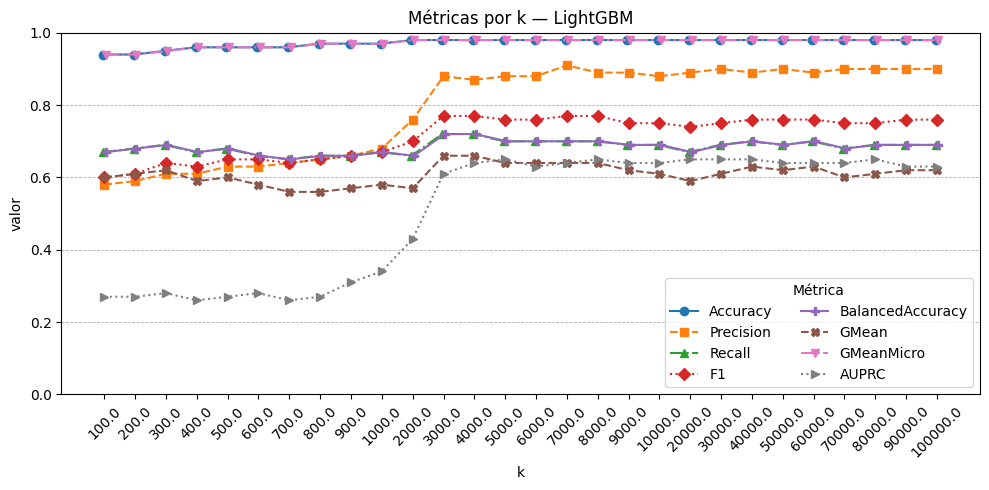

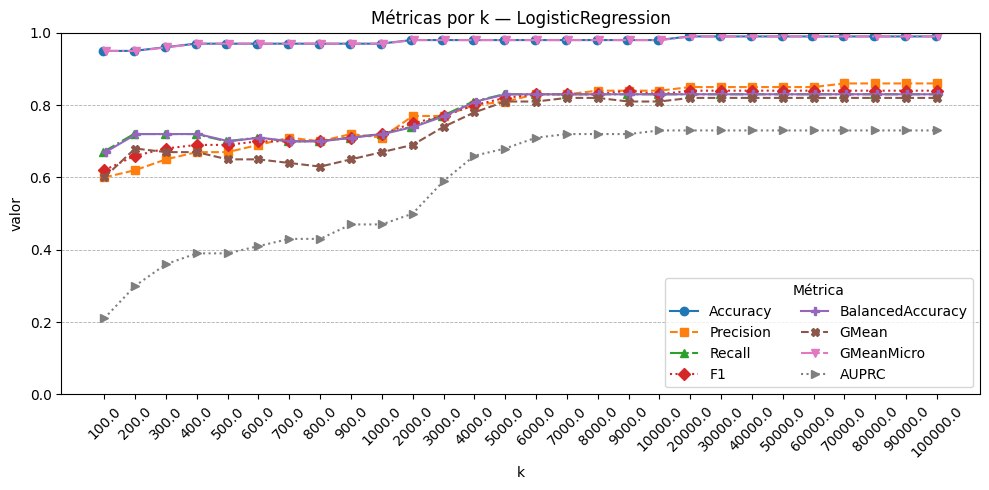

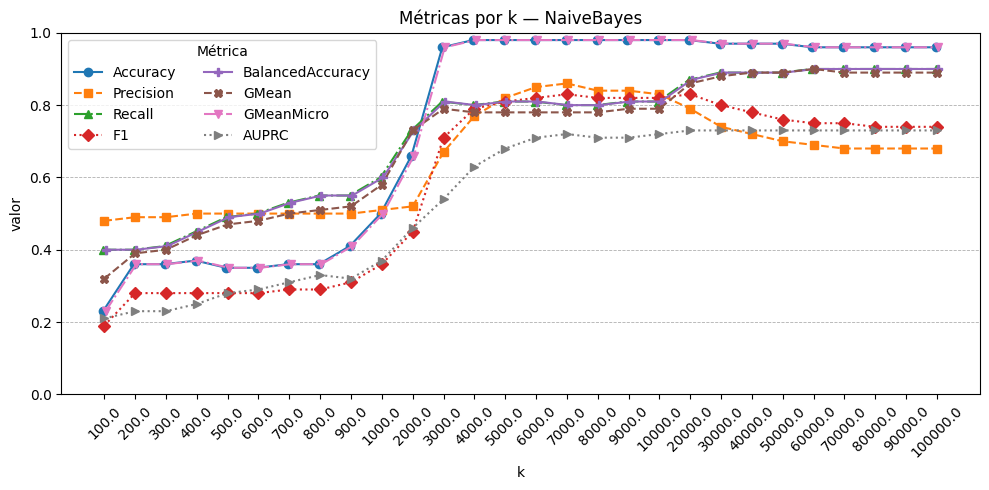

,Modelo,k,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,_k_num
0,LightGBM,100.0,0.94,0.58,0.67,0.60,0.67,0.60,0.94,0.27,100.0
1,LightGBM,200.0,0.94,0.59,0.68,0.61,0.68,0.61,0.94,0.27,200.0
2,LightGBM,300.0,0.95,0.61,0.69,0.64,0.69,0.62,0.95,0.28,300.0
3,LightGBM,400.0,0.96,0.61,0.67,0.63,0.67,0.59,0.96,0.26,400.0
4,LightGBM,500.0,0.96,0.63,0.68,0.65,0.68,0.60,0.96,0.27,500.0
...,...,...,...,...,...,...,...,...,...,...,...
79,NaiveBayes,60000.0,0.96,0.69,0.90,0.75,0.90,0.90,0.96,0.73,60000.0
80,NaiveBayes,70000.0,0.96,0.68,0.90,0.75,0.90,0.89,0.96,0.73,70000.0
81,NaiveBayes,80000.0,0.96,0.68,0.90,0.74,0.90,0.89,0.96,0.73,80000.0
82,NaiveBayes,90000.0,0.96,0.68,0.90,0.74,0.90,0.89,0.96,0.73,90000.0


In [7]:
plot_metrics_all_in_one_per_model(df_cv_final)

# Comportamento no conjunto de teste
- Não é exatamente identico, porém apresenta uma evolução semelhante

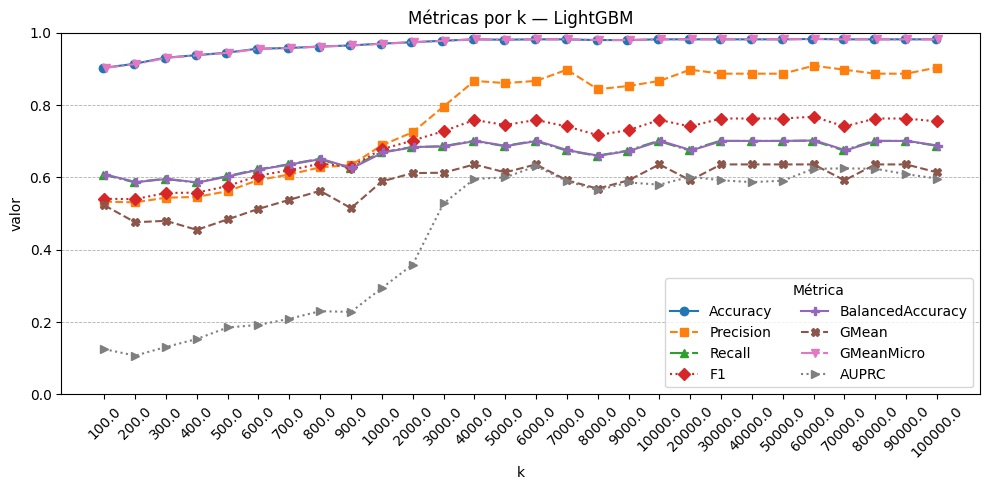

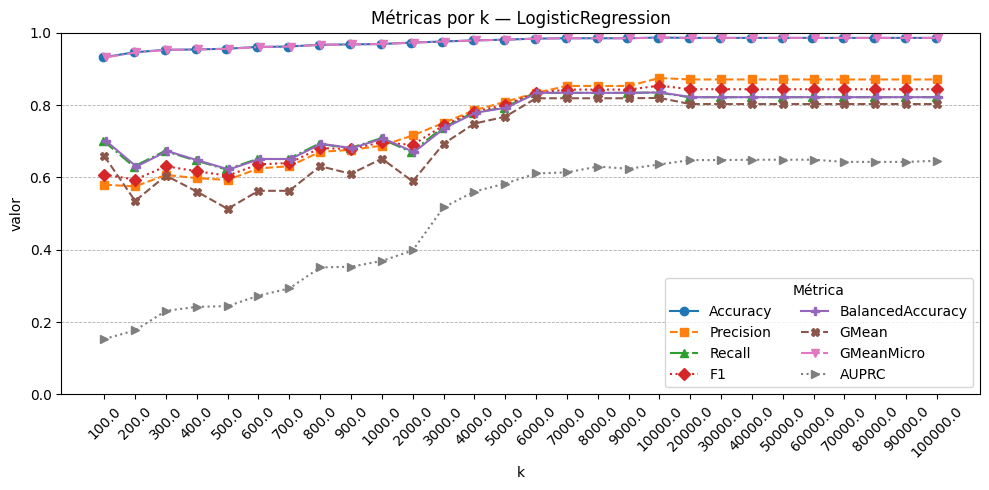

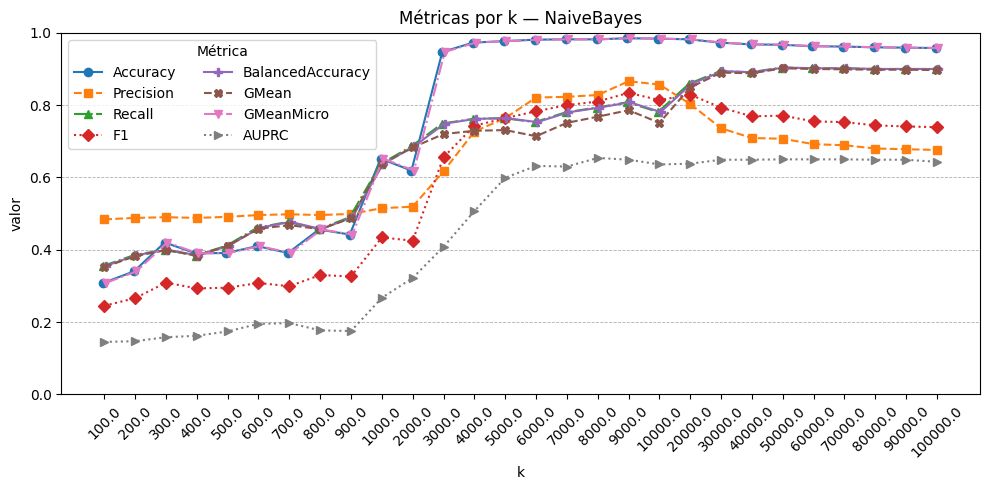

,Modelo,k,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,_k_num
0,LightGBM,100.0,0.903,0.533,0.608,0.541,0.608,0.523,0.903,0.125,100.0
1,LightGBM,200.0,0.914,0.531,0.587,0.540,0.587,0.476,0.914,0.107,200.0
2,LightGBM,300.0,0.931,0.544,0.596,0.557,0.596,0.480,0.931,0.131,300.0
3,LightGBM,400.0,0.938,0.546,0.586,0.558,0.586,0.455,0.938,0.153,400.0
4,LightGBM,500.0,0.945,0.562,0.603,0.576,0.603,0.484,0.945,0.185,500.0
...,...,...,...,...,...,...,...,...,...,...,...
79,NaiveBayes,60000.0,0.963,0.692,0.902,0.755,0.902,0.900,0.963,0.650,60000.0
80,NaiveBayes,70000.0,0.962,0.689,0.902,0.753,0.902,0.899,0.962,0.650,70000.0
81,NaiveBayes,80000.0,0.960,0.680,0.900,0.744,0.900,0.898,0.960,0.649,80000.0
82,NaiveBayes,90000.0,0.959,0.678,0.900,0.741,0.900,0.898,0.959,0.649,90000.0


In [8]:
plot_metrics_all_in_one_per_model(df_test_final)